<a href="https://colab.research.google.com/github/ota0425/brain-tumor-adversarial-experiment/blob/main/brain_tumor_adversarial_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MRI脳腫瘍画像のAdversarial Attack検知

既存のMobileNetV2脳腫瘍4クラス分類モデルを利用し、入力MRI画像がcleanかadversarialかを判定する二値検知モデルを構築する。

このNotebookは、攻撃生成・脆弱性評価を行う`brain_tumor_adversarial_examples.ipynb`と分離する。

## 実験フェーズ

1. **実験基盤の準備**（実装済み）
2. **検知用clean/adversarialデータの生成**（実装済み）
3. **MobileNetV2特徴を使った二値検知器の学習**（実装済み）
4. 既知εと未知εの評価
5. 発展：PGDなど未知攻撃の評価


## Step 1. 実験基盤の準備

このステップでは、分類モデルとデータセットを再現し、検知実験の前提が整っていることを確認する。

完了条件：

- TensorFlowとGPUを認識できる
- Google Drive上のデータセットと保存済みモデルを読み込める
- Training、Validation、Testingのクラス順が一致する
- Testing 1,600枚に対するclean Accuracyが既存結果の83.19%前後になる


In [3]:
import os
import random
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("Random seed:", SEED)


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Random seed: 42


### 1.1 Google Driveとパスの準備

検知実験でも、攻撃実験と同じデータセットZIPと保存済みベースラインモデルを使用する。


In [4]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [5]:
DRIVE_ROOT = Path("/content/drive/MyDrive/ThammasatResearch")
DATASET_ZIP_PATH = DRIVE_ROOT / "dataset" / "archive.zip"
EXTRACT_ROOT = Path("/content/brain_tumor")
TRAINING_DIRECTORY = EXTRACT_ROOT / "Training"
TESTING_DIRECTORY = EXTRACT_ROOT / "Testing"
CLASSIFIER_MODEL_PATH = (
    DRIVE_ROOT / "models" / "baseline_mobilenetv2.keras"
)
DETECTION_RESULTS_DIRECTORY = DRIVE_ROOT / "results" / "detection"
DETECTION_MODELS_DIRECTORY = DRIVE_ROOT / "models" / "detection"

assert DATASET_ZIP_PATH.exists(), (
    f"Dataset ZIP was not found: {DATASET_ZIP_PATH}"
)
assert CLASSIFIER_MODEL_PATH.exists(), (
    f"Classifier model was not found: {CLASSIFIER_MODEL_PATH}"
)

DETECTION_RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)
DETECTION_MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Dataset ZIP:", DATASET_ZIP_PATH)
print("Classifier model:", CLASSIFIER_MODEL_PATH)
print("Detection results:", DETECTION_RESULTS_DIRECTORY)
print("Detection models:", DETECTION_MODELS_DIRECTORY)


Dataset ZIP: /content/drive/MyDrive/ThammasatResearch/dataset/archive.zip
Classifier model: /content/drive/MyDrive/ThammasatResearch/models/baseline_mobilenetv2.keras
Detection results: /content/drive/MyDrive/ThammasatResearch/results/detection
Detection models: /content/drive/MyDrive/ThammasatResearch/models/detection


In [6]:
if TRAINING_DIRECTORY.exists() and TESTING_DIRECTORY.exists():
    print("Dataset is already extracted:", EXTRACT_ROOT)
else:
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(DATASET_ZIP_PATH, "r") as zip_file:
        zip_file.extractall(EXTRACT_ROOT)
    print("Dataset extracted:", EXTRACT_ROOT)

assert TRAINING_DIRECTORY.exists(), TRAINING_DIRECTORY
assert TESTING_DIRECTORY.exists(), TESTING_DIRECTORY


Dataset extracted: /content/brain_tumor


### 1.2 データセットの再構築

既存分類実験と同じ画像サイズ、バッチサイズ、乱数シード、Training/Validation分割を使用する。`class_names`はprefetch前に保存する。


In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAINING_DIRECTORY,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAINING_DIRECTORY,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TESTING_DIRECTORY,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

class_names = list(train_dataset.class_names)
validation_class_names = list(validation_dataset.class_names)
test_class_names = list(test_dataset.class_names)

assert class_names == validation_class_names == test_class_names, (
    class_names,
    validation_class_names,
    test_class_names,
)

print("Class names:", class_names)


Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [8]:
autotune = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(autotune)
validation_dataset = validation_dataset.prefetch(autotune)
test_dataset = test_dataset.prefetch(autotune)

sample_images, sample_labels = next(iter(test_dataset))

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Pixel range:", float(tf.reduce_min(sample_images)),
      "to", float(tf.reduce_max(sample_images)))


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0


### 1.3 保存済み分類モデルの再現確認

検知用adversarial画像はこの分類モデルに対して生成する。検知データを作る前に、cleanのTesting結果が既存実験と一致することを確認する。


In [9]:
classifier_model = tf.keras.models.load_model(CLASSIFIER_MODEL_PATH)
classifier_model.trainable = False

print("Classifier loaded successfully.")
print("Input shape:", classifier_model.input_shape)
print("Output shape:", classifier_model.output_shape)


Classifier loaded successfully.
Input shape: (None, 224, 224, 3)
Output shape: (None, 4)


In [10]:
clean_test_loss, clean_test_accuracy = classifier_model.evaluate(
    test_dataset,
    verbose=1,
)

EXPECTED_CLEAN_ACCURACY = 0.8319
ACCURACY_TOLERANCE = 0.005

print(f"Clean Test Loss: {clean_test_loss:.4f}")
print(f"Clean Test Accuracy: {clean_test_accuracy:.4f}")
print(f"Clean Test Accuracy: {clean_test_accuracy * 100:.2f}%")

if abs(clean_test_accuracy - EXPECTED_CLEAN_ACCURACY) > ACCURACY_TOLERANCE:
    raise RuntimeError(
        "Clean accuracy does not match the recorded baseline. "
        f"Expected about {EXPECTED_CLEAN_ACCURACY:.4f}, "
        f"but received {clean_test_accuracy:.4f}."
    )

print("Step 1 completed: experiment prerequisites are reproducible.")


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.8319 - loss: 0.5203
Clean Test Loss: 0.5203
Clean Test Accuracy: 0.8319
Clean Test Accuracy: 83.19%
Step 1 completed: experiment prerequisites are reproducible.


## Step 1 checkpoint

Step 1はここまでとする。上のセルで`Step 1 completed`が表示されたことを確認した後、次のステップで検知用clean/adversarialデータを生成する。

予定しているε（0–255スケール）：

- 検知器の学習：0.01, 0.1, 0.5
- 未知εの評価：0.05, 0.25, 1


## Step 2. clean/adversarial検知データの生成

既存分類モデルに対してuntargeted white-box FGSMを適用し、検知器の入力と二値ラベルをバッチ単位で生成する。

| 入力 | 検知ラベル |
|---|---:|
| clean MRI | 0 |
| FGSM adversarial MRI | 1 |

すべてのadversarial画像をラベル1とする。分類攻撃の成功・失敗は、後の評価でサブグループとして分ける。

大量の画像ファイルを複製せず、`tf.data`上でバッチごとに生成する。分類モデルは常に`training=False`で使用し、重みを更新しない。


In [11]:
TRAIN_EPSILONS = (0.01, 0.1, 0.5)
UNSEEN_EPSILONS = (0.05, 0.25, 1.0)
ALL_EVALUATION_EPSILONS = (
    *TRAIN_EPSILONS,
    *UNSEEN_EPSILONS,
)

train_epsilon_tensor = tf.constant(TRAIN_EPSILONS, tf.float32)
classification_loss = (
    tf.keras.losses.SparseCategoricalCrossentropy()
)

print("Training epsilons:", TRAIN_EPSILONS)
print("Unseen evaluation epsilons:", UNSEEN_EPSILONS)


Training epsilons: (0.01, 0.1, 0.5)
Unseen evaluation epsilons: (0.05, 0.25, 1.0)


In [12]:
@tf.function
def compute_fgsm_direction(images, tumor_labels):
    """Return clean predictions and the sign of d(loss)/d(images)."""
    images = tf.cast(images, tf.float32)
    tumor_labels = tf.cast(tumor_labels, tf.int32)

    with tf.GradientTape() as tape:
        tape.watch(images)
        clean_predictions = classifier_model(
            images,
            training=False,
        )
        loss = classification_loss(
            tumor_labels,
            clean_predictions,
        )

    gradients = tape.gradient(loss, images)
    if gradients is None:
        raise RuntimeError("FGSM input gradients could not be computed.")

    return clean_predictions, tf.sign(gradients)


@tf.function
def create_adversarial_images(images, signed_gradients, epsilon):
    """Create FGSM images on the model's 0-255 input scale."""
    images = tf.cast(images, tf.float32)
    epsilon = tf.cast(epsilon, tf.float32)
    adversarial_images = images + epsilon * signed_gradients
    return tf.clip_by_value(adversarial_images, 0.0, 255.0)


@tf.function
def build_detection_batch(
    images,
    tumor_labels,
    epsilon,
    shuffle_output=False,
):
    """Build a balanced batch of clean=0 and adversarial=1 images."""
    _, signed_gradients = compute_fgsm_direction(
        images,
        tumor_labels,
    )
    adversarial_images = create_adversarial_images(
        images,
        signed_gradients,
        epsilon,
    )

    batch_size = tf.shape(images)[0]
    detection_images = tf.concat(
        [tf.cast(images, tf.float32), adversarial_images],
        axis=0,
    )
    detection_labels = tf.concat(
        [
            tf.zeros((batch_size, 1), tf.float32),
            tf.ones((batch_size, 1), tf.float32),
        ],
        axis=0,
    )

    if shuffle_output:
        indices = tf.random.shuffle(
            tf.range(tf.shape(detection_images)[0]),
            seed=SEED,
        )
        detection_images = tf.gather(detection_images, indices)
        detection_labels = tf.gather(detection_labels, indices)

    return detection_images, detection_labels


print("FGSM detection-data functions are ready.")


FGSM detection-data functions are ready.


### 2.1 学習パイプライン

各Trainingバッチにε=0.01, 0.1, 0.5を順番に割り当てる。各元画像に対しcleanとadversarialを1枚ずつ作り、ラベル数を1:1にする。Trainingは毎epochシャッフルされるため、画像とεの組み合わせもepoch間で変化する。


In [13]:
def make_training_detection_batch(batch_index, source_batch):
    images, tumor_labels = source_batch
    epsilon_index = tf.cast(
        batch_index % len(TRAIN_EPSILONS),
        tf.int32,
    )
    epsilon = tf.gather(train_epsilon_tensor, epsilon_index)
    return build_detection_batch(
        images,
        tumor_labels,
        epsilon,
        shuffle_output=True,
    )


train_detection_dataset = (
    train_dataset
    .enumerate()
    .map(
        make_training_detection_batch,
        num_parallel_calls=1,
    )
    .prefetch(1)
)

print("Training detection pipeline is ready.")


Training detection pipeline is ready.


### 2.2 ValidationとTestingの評価パイプライン

Validationは検知器の学習と閾値決定に使用する。Testingは最終評価専用とし、検知閾値の調整に使用しない。

Testingはεごとに独立したデータセットを作り、既知εと未知εを分けて報告できるようにする。


In [14]:
def make_fixed_epsilon_detection_dataset(source_dataset, epsilon):
    epsilon_tensor = tf.constant(epsilon, tf.float32)

    def map_batch(images, tumor_labels):
        return build_detection_batch(
            images,
            tumor_labels,
            epsilon_tensor,
            shuffle_output=False,
        )

    return source_dataset.map(
        map_batch,
        num_parallel_calls=1,
    ).prefetch(1)


known_validation_datasets = {
    epsilon: make_fixed_epsilon_detection_dataset(
        validation_dataset,
        epsilon,
    )
    for epsilon in TRAIN_EPSILONS
}

validation_detection_dataset = None
for epsilon in TRAIN_EPSILONS:
    epsilon_dataset = known_validation_datasets[epsilon]
    if validation_detection_dataset is None:
        validation_detection_dataset = epsilon_dataset
    else:
        validation_detection_dataset = (
            validation_detection_dataset.concatenate(epsilon_dataset)
        )

known_test_detection_datasets = {
    epsilon: make_fixed_epsilon_detection_dataset(
        test_dataset,
        epsilon,
    )
    for epsilon in TRAIN_EPSILONS
}

unseen_test_detection_datasets = {
    epsilon: make_fixed_epsilon_detection_dataset(
        test_dataset,
        epsilon,
    )
    for epsilon in UNSEEN_EPSILONS
}

print("Known validation epsilons:",
      tuple(known_validation_datasets.keys()))
print("Known test epsilons:",
      tuple(known_test_detection_datasets.keys()))
print("Unseen test epsilons:",
      tuple(unseen_test_detection_datasets.keys()))


Known validation epsilons: (0.01, 0.1, 0.5)
Known test epsilons: (0.01, 0.1, 0.5)
Unseen test epsilons: (0.05, 0.25, 1.0)


### 2.3 生成データの健全性確認

ε=0.1の1バッチを使い、画素範囲、検知ラベル数、摂動の最大値、元画像とadversarial画像を確認する。


In [15]:
SANITY_CHECK_EPSILON = 0.1
sanity_clean_images, sanity_tumor_labels = next(iter(train_dataset))
sanity_clean_predictions, sanity_signed_gradients = (
    compute_fgsm_direction(
        sanity_clean_images,
        sanity_tumor_labels,
    )
)
sanity_adversarial_images = create_adversarial_images(
    sanity_clean_images,
    sanity_signed_gradients,
    SANITY_CHECK_EPSILON,
)
sanity_adversarial_predictions = classifier_model(
    sanity_adversarial_images,
    training=False,
)

sanity_detection_images, sanity_detection_labels = (
    build_detection_batch(
        sanity_clean_images,
        sanity_tumor_labels,
        SANITY_CHECK_EPSILON,
        shuffle_output=False,
    )
)

perturbation = (
    sanity_adversarial_images - tf.cast(sanity_clean_images, tf.float32)
)
maximum_absolute_perturbation = float(
    tf.reduce_max(tf.abs(perturbation))
)
clean_label_count = int(tf.reduce_sum(
    tf.cast(sanity_detection_labels == 0, tf.int32)
))
adversarial_label_count = int(tf.reduce_sum(
    tf.cast(sanity_detection_labels == 1, tf.int32)
))

clean_predicted_classes = tf.argmax(
    sanity_clean_predictions,
    axis=1,
)
adversarial_predicted_classes = tf.argmax(
    sanity_adversarial_predictions,
    axis=1,
)
changed_predictions = int(tf.reduce_sum(tf.cast(
    clean_predicted_classes != adversarial_predicted_classes,
    tf.int32,
)))

assert sanity_detection_images.shape[0] == 2 * sanity_clean_images.shape[0]
assert clean_label_count == adversarial_label_count
assert float(tf.reduce_min(sanity_detection_images)) >= 0.0
assert float(tf.reduce_max(sanity_detection_images)) <= 255.0
assert maximum_absolute_perturbation <= SANITY_CHECK_EPSILON + 1e-5

print("Detection batch shape:", sanity_detection_images.shape)
print("Clean labels:", clean_label_count)
print("Adversarial labels:", adversarial_label_count)
print("Maximum |perturbation|:", maximum_absolute_perturbation)
print("Changed predictions in this batch:", changed_predictions)
print("Step 2 completed: detection-data pipelines are ready.")


Detection batch shape: (64, 224, 224, 3)
Clean labels: 32
Adversarial labels: 32
Maximum |perturbation|: 0.100006103515625
Changed predictions in this batch: 12
Step 2 completed: detection-data pipelines are ready.


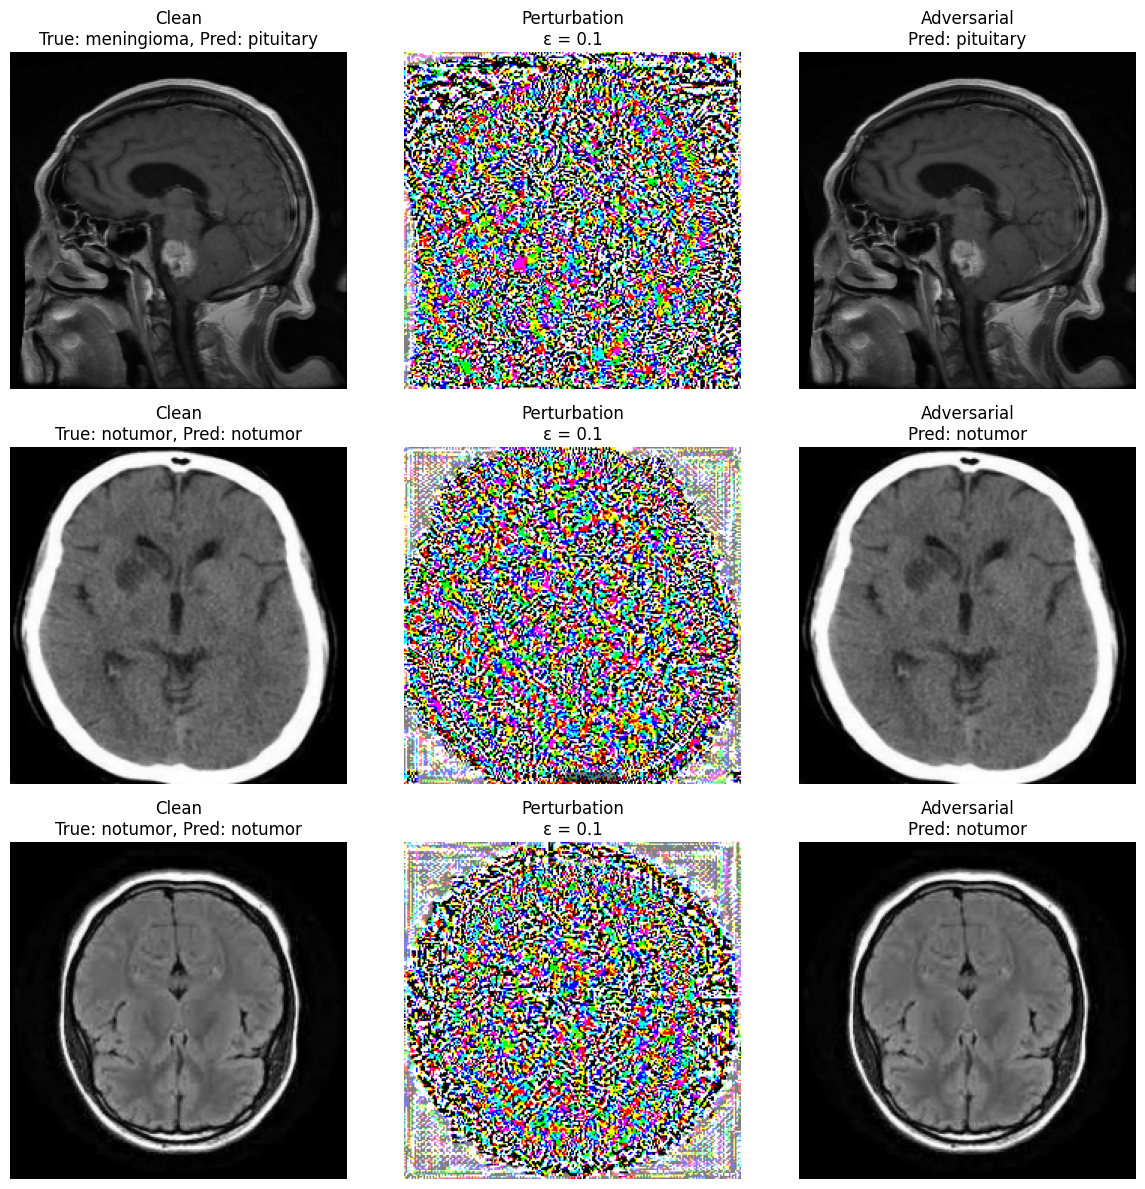

In [16]:
number_of_examples = 3
fig, axes = plt.subplots(
    number_of_examples,
    3,
    figsize=(12, 4 * number_of_examples),
)

for index in range(number_of_examples):
    original = sanity_clean_images[index].numpy()
    adversarial = sanity_adversarial_images[index].numpy()
    difference = adversarial - original
    difference_display = (
        difference + SANITY_CHECK_EPSILON
    ) / (2 * SANITY_CHECK_EPSILON)

    true_name = class_names[int(sanity_tumor_labels[index])]
    clean_name = class_names[int(clean_predicted_classes[index])]
    adversarial_name = class_names[
        int(adversarial_predicted_classes[index])
    ]

    axes[index, 0].imshow(original.astype(np.uint8))
    axes[index, 0].set_title(
        f"Clean\nTrue: {true_name}, Pred: {clean_name}"
    )
    axes[index, 0].axis("off")

    axes[index, 1].imshow(
        np.clip(difference_display, 0, 1)
    )
    axes[index, 1].set_title(
        f"Perturbation\nε = {SANITY_CHECK_EPSILON}"
    )
    axes[index, 1].axis("off")

    axes[index, 2].imshow(adversarial.astype(np.uint8))
    axes[index, 2].set_title(
        f"Adversarial\nPred: {adversarial_name}"
    )
    axes[index, 2].axis("off")

plt.tight_layout()
plt.show()


## Step 2 checkpoint

Step 2はここまでとする。`Step 2 completed`が表示され、clean/adversarialが同数で、最大摂動がε以下であることを確認する。

次のStep 3では、既存MobileNetV2の内部特徴を入力とする二値検知ヘッドを作成し、検知器の学習を行う。


## Step 3. MobileNetV2特徴を使った二値検知器の学習

既存分類モデルの`GlobalAveragePooling2D`出力を内部特徴として使用し、clean/adversarialを判定する小さな検知ヘッドを接続する。

分類モデルと特徴抽出器は凍結し、検知ヘッドだけを学習する。これにより、攻撃実験で確定した腫瘍分類モデルの重みを変更しない。

検知モデルの初期構成：

~~~text
224×224×3 MRI
  → 凍結済みMobileNetV2特徴（1280次元）
  → Dense(128, ReLU, L2)
  → Dropout(0.3)
  → Dense(1, Sigmoid)
~~~


In [17]:
feature_layer = next(
    (
        layer
        for layer in reversed(classifier_model.layers)
        if isinstance(
            layer,
            tf.keras.layers.GlobalAveragePooling2D,
        )
    ),
    None,
)

if feature_layer is None:
    raise RuntimeError(
        "GlobalAveragePooling2D layer was not found in the classifier."
    )

feature_extractor = tf.keras.Model(
    inputs=classifier_model.input,
    outputs=feature_layer.output,
    name="frozen_classifier_feature_extractor",
)
feature_extractor.trainable = False

sample_features = feature_extractor(
    sanity_clean_images,
    training=False,
)

print("Feature layer:", feature_layer.name)
print("Feature shape:", sample_features.shape)
print("Feature extractor trainable:", feature_extractor.trainable)


Feature layer: global_average_pooling2d_1
Feature shape: (32, 1280)
Feature extractor trainable: False


In [18]:
detector_inputs = tf.keras.Input(
    shape=(*IMAGE_SIZE, 3),
    name="mri_image",
)
detector_features = feature_extractor(
    detector_inputs,
    training=False,
)
detector_hidden = tf.keras.layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name="detector_dense",
)(detector_features)
detector_hidden = tf.keras.layers.Dropout(
    0.3,
    name="detector_dropout",
)(detector_hidden)
detector_outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="adversarial_probability",
)(detector_hidden)

detector_model = tf.keras.Model(
    inputs=detector_inputs,
    outputs=detector_outputs,
    name="fgsm_feature_detector",
)

detector_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="binary_accuracy",
        ),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

detector_model.summary()

trainable_parameters = int(np.sum([
    np.prod(variable.shape)
    for variable in detector_model.trainable_weights
]))
total_parameters = detector_model.count_params()

print("Trainable detector parameters:", trainable_parameters)
print("Total parameters including frozen extractor:",
      total_parameters)


Model: "fgsm_feature_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mri_image (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frozen_classifier_feature_extr… │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ detector_dense (Dense)          │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ detector_dropout (Dropout)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adversarial_probability (Dense) │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Trainable detector parameters: 164097
Total parameters including frozen extractor: 2422081


### 3.1 学習条件

- Loss: Binary Crossentropy
- Optimizer: Adam, learning rate = 0.001
- 最大epoch: 20
- ベストモデルの基準: Validation ROC-AUC
- EarlyStopping patience: 4
- ReduceLROnPlateau patience: 2

Validationは学習用の既知ε=0.01, 0.1, 0.5のみを使用する。Testingと未知εは学習やモデル選択に使用しない。


In [19]:
MAX_DETECTOR_EPOCHS = 20
DETECTOR_MODEL_PATH = (
    DETECTION_MODELS_DIRECTORY / "fgsm_feature_detector.keras"
)
DETECTOR_HISTORY_PATH = (
    DETECTION_RESULTS_DIRECTORY / "detector_training_history.csv"
)
DETECTOR_CURVES_PATH = (
    DETECTION_RESULTS_DIRECTORY / "detector_training_curves.png"
)

detector_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=DETECTOR_MODEL_PATH,
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_roc_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("Best detector model path:", DETECTOR_MODEL_PATH)


Best detector model path: /content/drive/MyDrive/ThammasatResearch/models/detection/fgsm_feature_detector.keras


In [20]:
detector_history = detector_model.fit(
    train_detection_dataset,
    validation_data=validation_detection_dataset,
    epochs=MAX_DETECTOR_EPOCHS,
    callbacks=detector_callbacks,
    verbose=1,
)


Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - binary_accuracy: 0.5040 - loss: 0.7688 - pr_auc: 0.5028 - precision: 0.5041 - recall: 0.5087 - roc_auc: 0.5046
Epoch 1: val_roc_auc improved from None to 0.59476, saving model to /content/drive/MyDrive/ThammasatResearch/models/detection/fgsm_feature_detector.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ThammasatResearch/models/detection/fgsm_feature_detector.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 656s 5s/step - binary_accuracy: 0.5015 - loss: 0.7320 - pr_auc: 0.5036 - precision: 0.5015 - recall: 0.4777 - roc_auc: 0.5062 - val_binary_accuracy: 0.5592 - val_loss: 0.7059 - val_pr_auc: 0.5734 - val_precision: 0.5941 - val_recall: 0.3738 - val_roc_auc: 0.5948 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - binary_accuracy: 0.4988 - loss: 0.7127 - pr_auc: 0.5033 - precision: 0.4988 - recall: 0.4787 - roc_auc: 0.5065
Epoch 2: val_roc_auc did not improve from 0.59476
140/140 ━━━━━━━━━━━━━━━━━━━━ 67

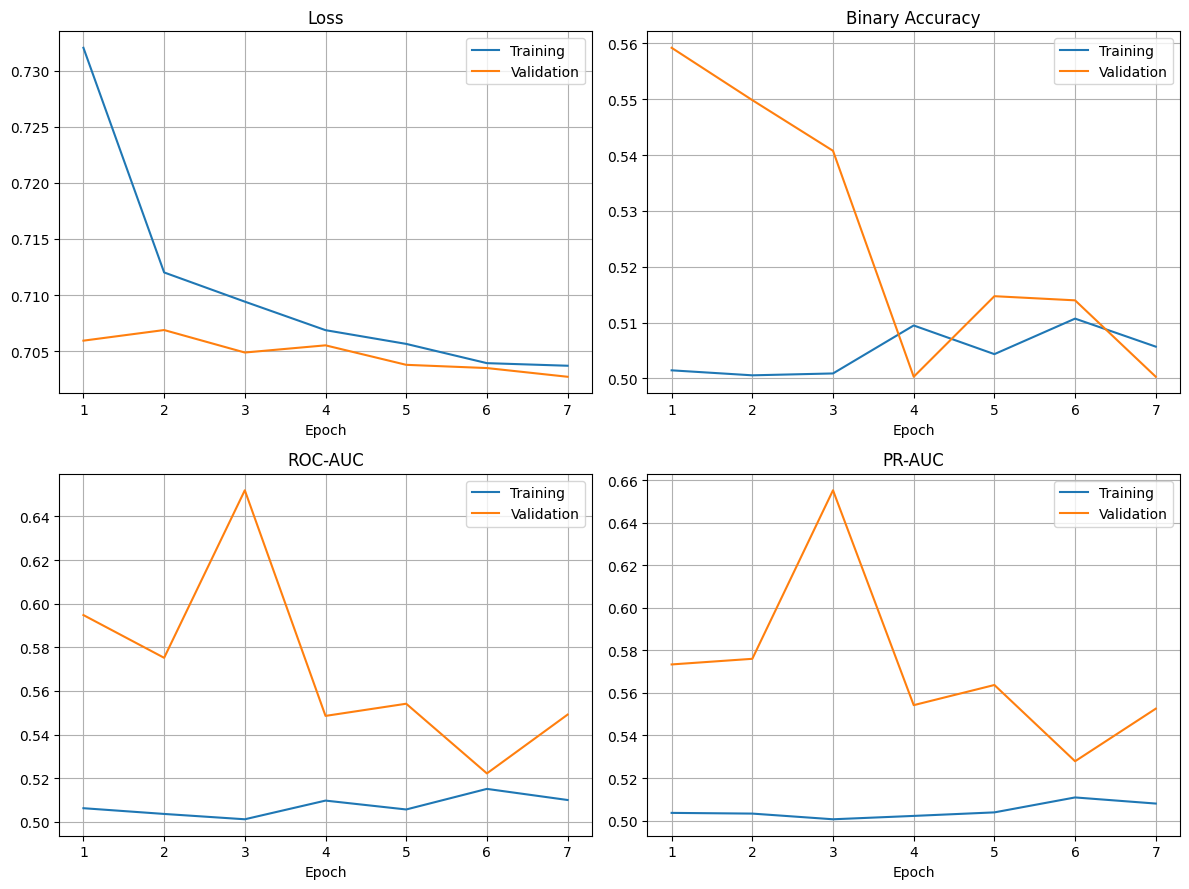

Saved: /content/drive/MyDrive/ThammasatResearch/results/detection/detector_training_history.csv
Saved: /content/drive/MyDrive/ThammasatResearch/results/detection/detector_training_curves.png


In [21]:
detector_history_df = pd.DataFrame(detector_history.history)
detector_history_df.index = np.arange(
    1,
    len(detector_history_df) + 1,
)
detector_history_df.index.name = "epoch"
detector_history_df.to_csv(DETECTOR_HISTORY_PATH)

metric_pairs = [
    ("loss", "Loss"),
    ("binary_accuracy", "Binary Accuracy"),
    ("roc_auc", "ROC-AUC"),
    ("pr_auc", "PR-AUC"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for axis, (metric_name, title) in zip(axes.flat, metric_pairs):
    axis.plot(
        detector_history_df.index,
        detector_history_df[metric_name],
        label="Training",
    )
    axis.plot(
        detector_history_df.index,
        detector_history_df[f"val_{metric_name}"],
        label="Validation",
    )
    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.grid(True)
    axis.legend()

plt.tight_layout()
plt.savefig(
    DETECTOR_CURVES_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", DETECTOR_HISTORY_PATH)
print("Saved:", DETECTOR_CURVES_PATH)


### 3.2 ベストモデルのValidation確認

Validation全体に対する検知指標を確認する。ここでは基本閾値0.5を使う。FPR=1%の閾値決定とε別評価は後のStepで行う。


In [22]:
best_detector_model = tf.keras.models.load_model(
    DETECTOR_MODEL_PATH
)

validation_metrics = best_detector_model.evaluate(
    validation_detection_dataset,
    return_dict=True,
    verbose=1,
)

print("Validation metrics at threshold 0.5:")
for metric_name, metric_value in validation_metrics.items():
    print(f"  {metric_name}: {metric_value:.4f}")

validation_sample_images, validation_sample_labels = next(
    iter(validation_detection_dataset)
)
validation_sample_scores = best_detector_model(
    validation_sample_images,
    training=False,
).numpy().reshape(-1)

assert np.all(validation_sample_scores >= 0.0)
assert np.all(validation_sample_scores <= 1.0)
assert validation_sample_scores.shape[0] == (
    validation_sample_labels.shape[0]
)

print("Sample adversarial-score range:",
      float(validation_sample_scores.min()),
      "to",
      float(validation_sample_scores.max()))
print("Step 3 completed: detector training and validation finished.")


105/105 ━━━━━━━━━━━━━━━━━━━━ 278s 3s/step - binary_accuracy: 0.5408 - loss: 0.7049 - pr_auc: 0.6552 - precision: 0.8425 - recall: 0.1003 - roc_auc: 0.6520
Validation metrics at threshold 0.5:
  binary_accuracy: 0.5408
  loss: 0.7049
  pr_auc: 0.6552
  precision: 0.8425
  recall: 0.1003
  roc_auc: 0.6520
Sample adversarial-score range: 0.4794660806655884 to 0.49822261929512024
Step 3 completed: detector training and validation finished.


## Stop point after Step 3

Step 3はここまでとする。`Step 3 completed`が表示され、Google Driveにベスト検知モデル、学習履歴CSV、学習曲線が保存されたことを確認する。

次のStep 4では、Testingデータの既知ε=0.01, 0.1, 0.5を個別に評価する。Testingの数値は検知閾値やモデル選択に使用しない。
